# RuBisCO Protein Generation with Structural Features
Enhanced diffusion model incorporating 3D structural data for stable protein generation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
import ast

# Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


# Load Structural Data CSV

In [3]:
# Load structural data CSV
df = pd.read_csv('protein_structural_dataset.csv')

print(f"Loaded {len(df)} proteins with structural data")
print(f"Columns: {df.columns.tolist()}")
print(f"\nDataset shape: {df.shape}")
df.head()

Loaded 9289 proteins with structural data
Columns: ['protein_id', 'sequence', 'coordinates', 'confidence_mask', 'secondary_structure', 'phi_angles', 'psi_angles', 'neighbor_count']

Dataset shape: (9289, 8)


,protein_id,sequence,coordinates,confidence_mask,secondary_structure,phi_angles,psi_angles,neighbor_count
0,AF-A0A075IPS9,GNNQGMGDIEHAKMIDFYVPQEVVRQFDCPTTNIEELWRILGRPTK...,"[(10.195, -12.387, -18.035), (12.307, -14.849,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",-GGGG-TT-S--EE------HHHHTTS---S--HHHHHHHTT--SS...,"[360.0, -56.2, -57.0, -77.7, -120.9, -60.6, -7...","[-139.7, -31.1, -22.0, -2.4, 10.1, 122.3, -13....","[4, 5, 5, 9, 6, 7, 5, 4, 6, 5, 7, 9, 9, 10, 10..."
1,AF-A0A0A7LWC5,KASVGFKAGVKDYKLTYYTPDYETKDTDILAAFRVTPQPGVPPEEA...,"[(38.541, -16.912, -15.934), (37.06, -13.541, ...","[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",-PPTT---S---THHHHB-TTPPPPTT-EEEEEEEEEPTT--HHHH...,"[360.0, -56.9, -68.2, -56.6, 123.1, -69.8, -12...","[107.2, 120.8, 139.2, 116.5, -8.8, 128.9, 116....","[2, 4, 6, 4, 4, 6, 5, 8, 6, 7, 8, 6, 11, 12, 7..."
2,AF-A0A075BZE6,KASVGFKAGVKDYKLNYYTPDYEVKDTDILAAFRVTPQPGVPPEEA...,"[(-4.421, 26.523, 25.773), (-5.443, 22.835, 26...","[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",---TT---S---THHHHB-TT----TT-EEEEEEEEEPTT--HHHH...,"[360.0, -59.3, -59.4, -57.8, 130.4, -69.7, -12...","[108.7, 126.2, 140.8, 107.2, -11.6, 126.8, 111...","[2, 5, 7, 4, 4, 7, 5, 8, 6, 7, 8, 6, 11, 12, 7..."
3,AF-A0A023HTG5,RAAAATGEVKGSYLNITAATMEEVYKRAEYAKAIGSVIVMIDLVMG...,"[(-7.892, -23.495, 3.622), (-8.424, -19.826, 4...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",-HHHHHSS-----EE---SSHHHHHHHHHHHHHTT-SEEEEEGGG-...,"[360.0, -54.4, -56.9, -67.4, -80.0, -115.2, 69...","[-70.2, -45.4, -42.6, -29.2, -23.7, -14.8, 14....","[4, 6, 9, 7, 6, 6, 6, 6, 5, 6, 7, 7, 8, 8, 7, ..."
4,AF-A0A0A0QMK3,SVGFKAGVKDYKLTYYTPEYETKPTDILAAFRVTPQPGVPPEEAGA...,"[(-6.594, 25.296, 26.148), (-9.252, 22.635, 25...","[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",------S---THHHHB-TT----TT-EEEEEEEEEPTT--HHHHHH...,"[360.0, -71.8, -60.0, -57.5, -117.6, -64.0, 13...","[122.1, 119.4, 114.2, 129.0, 111.0, 153.1, 169...","[3, 3, 4, 6, 5, 8, 6, 7, 8, 6, 11, 12, 7, 7, 1..."


# Data Preprocessing

In [4]:
# Function to convert string representations back to lists
def parse_list_string(s):
    """Convert string representation of list back to actual list"""
    try:
        return ast.literal_eval(s)
    except:
        return []

# Parse the structural features
print("Parsing structural features...")
df['coordinates_parsed'] = df['coordinates'].apply(parse_list_string)
df['confidence_mask_parsed'] = df['confidence_mask'].apply(parse_list_string)
df['phi_angles_parsed'] = df['phi_angles'].apply(parse_list_string)
df['psi_angles_parsed'] = df['psi_angles'].apply(parse_list_string)
df['neighbor_count_parsed'] = df['neighbor_count'].apply(parse_list_string)
df['secondary_structure_parsed'] = df['secondary_structure'].apply(lambda x: list(x) if isinstance(x, str) else [])

print(f"Example sequence length: {len(df.iloc[0]['sequence'])}")
print(f"Example coordinates length: {len(df.iloc[0]['coordinates_parsed'])}")
print(f"Example phi angles length: {len(df.iloc[0]['phi_angles_parsed'])}")
print(f"Example secondary structure length: {len(df.iloc[0]['secondary_structure_parsed'])}")

# Create secondary structure encoding
ss_to_idx = {'H': 0, 'E': 1, 'C': 2, 'G': 3, 'I': 4, 'B': 5, 'T': 6, 'S': 7, '-': 8}
print(f"Secondary structure codes: {list(ss_to_idx.keys())}")

Parsing structural features...
Example sequence length: 266
Example coordinates length: 266
Example phi angles length: 266
Example secondary structure length: 266
Secondary structure codes: ['H', 'E', 'C', 'G', 'I', 'B', 'T', 'S', '-']


## 🚨 IMPORTANT FIX: Secondary Structure Integration

**ISSUE DISCOVERED**: The original code was parsing the `secondary_structure` column but **NOT using it in the model**!

**FIXED**: 
- ✅ Added secondary structure parsing and encoding
- ✅ Added secondary structure embedding layer  
- ✅ Updated forward pass to include secondary structure
- ✅ Updated optimizer to train secondary structure parameters

**Now using ALL structural features:**
- Coordinates (3D positions)
- Phi/Psi angles (dihedral angles)
- Neighbor counts (local density)
- Confidence masks (quality scores)
- **Secondary structure (H/E/C/etc.)** ← NOW INCLUDED!

# Train/Test Data Split

In [5]:
# Split data into train and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Train size: {len(train_df)}, Val size: {len(val_df)}")
print(f"Total proteins: {len(df)}")

Train size: 7431, Val size: 1858
Total proteins: 9289


# Amino Acid Vocabulary Creation

In [6]:
def create_amino_acid_vocab():
    amino_acids = ['PAD', 'A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I',
                   'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']
    aa_to_idx = {aa: idx for idx, aa in enumerate(amino_acids)}
    idx_to_aa = {idx: aa for idx, aa in enumerate(amino_acids)}
    return aa_to_idx, idx_to_aa

aa_to_idx, idx_to_aa = create_amino_acid_vocab()
print(f"Vocabulary size: {len(aa_to_idx)}")
print(f"Amino acids: {list(aa_to_idx.keys())}")

Vocabulary size: 21
Amino acids: ['PAD', 'A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']


# Data Preparation for Training

In [7]:
def prepare_structural_data(dataframe, aa_to_idx, max_len=None):
    """
    Prepare structural features for model training
    """
    sequences = []
    coordinates = []
    phi_angles = []
    psi_angles = []
    neighbor_counts = []
    confidence_masks = []
    secondary_structures = []
    
    # Calculate max_len if not provided
    if max_len is None:
        max_len = max(len(row['sequence']) for _, row in dataframe.iterrows())
        max_len = ((max_len + 4) // 5) * 5  # Round up to nearest 5
    
    for idx, row in dataframe.iterrows():
        seq = row['sequence']
        coords = row['coordinates_parsed']
        phi = row['phi_angles_parsed']
        psi = row['psi_angles_parsed']
        neighbors = row['neighbor_count_parsed']
        conf_mask = row['confidence_mask_parsed']
        ss = row['secondary_structure_parsed']
        
        # Encode sequence
        encoded_seq = [aa_to_idx[aa] for aa in seq if aa in aa_to_idx]
        
        # Encode secondary structure
        encoded_ss = [ss_to_idx.get(s, 8) for s in ss]  # Default to '-' (coil)
        
        # Pad/truncate to max_len
        if len(encoded_seq) > max_len:
            encoded_seq = encoded_seq[:max_len]
            coords = coords[:max_len]
            phi = phi[:max_len]
            psi = psi[:max_len]
            neighbors = neighbors[:max_len]
            conf_mask = conf_mask[:max_len]
            encoded_ss = encoded_ss[:max_len]
        else:
            # Pad with zeros/defaults
            pad_len = max_len - len(encoded_seq)
            encoded_seq.extend([0] * pad_len)
            coords.extend([(0.0, 0.0, 0.0)] * pad_len)
            phi.extend([0.0] * pad_len)
            psi.extend([0.0] * pad_len)
            neighbors.extend([0] * pad_len)
            conf_mask.extend([0] * pad_len)
            encoded_ss.extend([8] * pad_len)  # Pad with 'coil' 
        
        sequences.append(encoded_seq)
        coordinates.append(coords)
        phi_angles.append(phi)
        psi_angles.append(psi)
        neighbor_counts.append(neighbors)
        confidence_masks.append(conf_mask)
        secondary_structures.append(encoded_ss)
    
    return {
        'sequences': torch.tensor(sequences, dtype=torch.long, device=device),
        'coordinates': torch.tensor(coordinates, dtype=torch.float, device=device),
        'phi_angles': torch.tensor(phi_angles, dtype=torch.float, device=device),
        'psi_angles': torch.tensor(psi_angles, dtype=torch.float, device=device),
        'neighbor_counts': torch.tensor(neighbor_counts, dtype=torch.float, device=device),
        'confidence_masks': torch.tensor(confidence_masks, dtype=torch.float, device=device),
        'secondary_structures': torch.tensor(secondary_structures, dtype=torch.long, device=device)
    }, max_len

# Prepare training and validation data
print("Preparing training data...")
train_data, max_len = prepare_structural_data(train_df, aa_to_idx)
print("Preparing validation data...")
val_data, _ = prepare_structural_data(val_df, aa_to_idx, max_len)

print(f"\nMax sequence length: {max_len}")
print(f"Training data shapes:")
for key, tensor in train_data.items():
    print(f"  {key}: {tensor.shape}")
    
print(f"\nSecondary structure vocabulary: {ss_to_idx}")
print(f"Example secondary structure codes: {train_data['secondary_structures'][0][:20]}")

Preparing training data...
Preparing validation data...

Max sequence length: 725
Training data shapes:
  sequences: torch.Size([7431, 725])
  coordinates: torch.Size([7431, 725, 3])
  phi_angles: torch.Size([7431, 725])
  psi_angles: torch.Size([7431, 725])
  neighbor_counts: torch.Size([7431, 725])
  confidence_masks: torch.Size([7431, 725])
  secondary_structures: torch.Size([7431, 725])

Secondary structure vocabulary: {'H': 0, 'E': 1, 'C': 2, 'G': 3, 'I': 4, 'B': 5, 'T': 6, 'S': 7, '-': 8}
Example secondary structure codes: tensor([8, 1, 1, 8, 6, 6, 8, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6])


# Model Configuration

In [8]:
# Model configuration
vocab_size = len(aa_to_idx)
d_model = 256
num_heads = 8
num_layers = 6
d_ff = 1024
dropout = 0.1

print(f"Model Configuration:")
print(f"  Vocabulary size: {vocab_size}")
print(f"  Model dimension: {d_model}")
print(f"  Number of heads: {num_heads}")
print(f"  Number of layers: {num_layers}")
print(f"  Max sequence length: {max_len}")

Model Configuration:
  Vocabulary size: 21
  Model dimension: 256
  Number of heads: 8
  Number of layers: 6
  Max sequence length: 725


# Model Components

## Embedding and Positional Encoding

In [9]:
# Sequence embedding
embedding = nn.Embedding(vocab_size, d_model, padding_idx=0).to(device)
pos_encoding = torch.nn.Parameter(torch.zeros(1, max_len, d_model, device=device), requires_grad=True)

# Structural feature embeddings
coordinate_projection = nn.Linear(3, d_model // 5).to(device)  # Project 3D coords
angle_projection = nn.Linear(2, d_model // 5).to(device)      # Project phi/psi angles
neighbor_projection = nn.Linear(1, d_model // 5).to(device)   # Project neighbor count
confidence_projection = nn.Linear(1, d_model // 5).to(device) # Project confidence
ss_embedding = nn.Embedding(len(ss_to_idx), d_model // 5).to(device)  # Secondary structure embedding

# Feature combination layer - now with 5 features
feature_projection = nn.Linear(d_model + 5 * (d_model // 5), d_model).to(device)

print("Embedding layers initialized")
print(f"Secondary structure embedding: {len(ss_to_idx)} classes -> {d_model // 5} dims")

Embedding layers initialized
Secondary structure embedding: 9 classes -> 51 dims


## Time Embedding for Diffusion

In [10]:
# Time embedding MLP to process timestep information
time_mlp = nn.Sequential(
    nn.Linear(d_model, d_model * 4),
    nn.SiLU(),
    nn.Linear(d_model * 4, d_model)
).to(device)

def create_time_embedding(timestep, dim):
    half_dim = dim // 2
    emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, device=timestep.device) * -emb)
    emb = timestep[:, None] * emb[None, :]
    emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
    return emb

print("Time embedding initialized")

Time embedding initialized


## Transformer Encoder

In [11]:
encoder_layer = nn.TransformerEncoderLayer(d_model=d_model,
                                           nhead=num_heads,
                                           dim_feedforward=d_ff,
                                           dropout=dropout,
                                           batch_first=True).to(device)

transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers).to(device)

print("Transformer encoder initialized")

Transformer encoder initialized


## Output Layer

In [12]:
output_layer = nn.Linear(d_model, vocab_size).to(device)  # Sequence prediction

# NEW: Structural prediction heads
coordinate_head = nn.Sequential(
    nn.Linear(d_model, d_model // 2),
    nn.ReLU(),
    nn.Linear(d_model // 2, 3)  # x, y, z coordinates
).to(device)

secondary_structure_head = nn.Sequential(
    nn.Linear(d_model, d_model // 2),
    nn.ReLU(),
    nn.Linear(d_model // 2, len(ss_to_idx))  # SS classes
).to(device)

angles_head = nn.Sequential(
    nn.Linear(d_model, d_model // 2),
    nn.ReLU(),
    nn.Linear(d_model // 2, 2)  # phi, psi angles
).to(device)

print("✅ MULTI-TASK OUTPUT HEADS INITIALIZED:")
print(f"  - Sequence prediction: {vocab_size} amino acids")
print(f"  - Coordinate prediction: 3D positions")
print(f"  - Secondary structure: {len(ss_to_idx)} classes")
print(f"  - Angle prediction: phi/psi dihedral angles")

✅ MULTI-TASK OUTPUT HEADS INITIALIZED:
  - Sequence prediction: 21 amino acids
  - Coordinate prediction: 3D positions
  - Secondary structure: 9 classes
  - Angle prediction: phi/psi dihedral angles


# Diffusion Schedule Creation

In [13]:
# Number of diffusion steps
T = 1000

# Beta schedule
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T).to(device)

# Alphas
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas[1:] * (1.0 - alphas_cumprod[:-1]) / (1.0 - alphas_cumprod[1:])
posterior_variance = torch.cat([torch.tensor([1e-8], device=device), posterior_variance])

print(f"Diffusion schedule created:")
print(f"  Number of steps (T): {T}")
print(f"  Beta range: {beta_start} to {beta_end}")
print(f"  Betas shape: {betas.shape}")
print(f"  Alphas cumulative product shape: {alphas_cumprod.shape}")

Diffusion schedule created:
  Number of steps (T): 1000
  Beta range: 0.0001 to 0.02
  Betas shape: torch.Size([1000])
  Alphas cumulative product shape: torch.Size([1000])


# Noise Sampling and Addition

In [14]:
def sample_timesteps(batch_size, T):
    return torch.randint(1, T + 1, (batch_size,), device=device)

def add_noise(x, t, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod, vocab_size):
    batch_size, seq_len = x.shape
    
    # Get corruption probability for this timestep
    alpha_t = sqrt_alphas_cumprod[t - 1]  # [batch_size]
    
    # Create noise mask: 1 where we corrupt, 0 where we keep original
    noise_mask = torch.bernoulli(1 - alpha_t.unsqueeze(1).expand(-1, seq_len))  # [batch_size, seq_len]
    
    # Sample random tokens for corruption
    noise_tokens = torch.randint(1, vocab_size, (batch_size, seq_len), device=x.device)
    
    # Apply corruption: keep original where mask=0, use noise where mask=1
    x_noisy = x * (1 - noise_mask.long()) + noise_tokens * noise_mask.long()
    
    return x_noisy, noise_mask

print("Noise functions defined")

Noise functions defined


# Enhanced Model Forward Pass

In [15]:
def enhanced_rubisco_diffusion_forward(x, t, mask, coords=None, angles=None, neighbors=None, confidence=None, secondary_structure=None):
    """
    Enhanced forward pass that predicts MULTIPLE structural outputs for stable protein generation
    """
    # Time embedding
    time_emb = create_time_embedding(t.float(), d_model)
    time_emb = time_mlp(time_emb)
    
    # Sequence embedding
    x_emb = embedding(x)  # [batch_size, seq_len, d_model]
    x_emb = x_emb + pos_encoding[:, :x.size(1), :]
    
    # Add structural features if available
    feature_embeddings = []
    
    if coords is not None:
        coord_emb = coordinate_projection(coords)  # [batch_size, seq_len, d_model//5]
        feature_embeddings.append(coord_emb)
    
    if angles is not None:
        angle_emb = angle_projection(angles)  # [batch_size, seq_len, d_model//5]
        feature_embeddings.append(angle_emb)
    
    if neighbors is not None:
        neighbor_emb = neighbor_projection(neighbors)  # [batch_size, seq_len, d_model//5]
        feature_embeddings.append(neighbor_emb)
    
    if confidence is not None:
        conf_emb = confidence_projection(confidence)  # [batch_size, seq_len, d_model//5]
        feature_embeddings.append(conf_emb)
    
    if secondary_structure is not None:
        ss_emb = ss_embedding(secondary_structure)  # [batch_size, seq_len, d_model//5]
        feature_embeddings.append(ss_emb)
    
    # Concatenate all features
    if feature_embeddings:
        all_features = torch.cat([x_emb] + feature_embeddings, dim=-1)
        x_emb = feature_projection(all_features)
    
    # Add time information
    time_emb = time_emb.unsqueeze(1)
    x_emb = x_emb + time_emb
    
    # Pass through transformer
    src_key_padding_mask = (mask == 0)
    transformer_out = transformer_encoder(x_emb, src_key_padding_mask=src_key_padding_mask)
    
    # MULTIPLE PREDICTION HEADS FOR STRUCTURAL LEARNING
    sequence_logits = output_layer(transformer_out)  # [batch_size, seq_len, vocab_size]
    coord_pred = coordinate_head(transformer_out)    # [batch_size, seq_len, 3] - 3D coordinates
    ss_pred = secondary_structure_head(transformer_out)  # [batch_size, seq_len, 9] - SS classes
    angles_pred = angles_head(transformer_out)       # [batch_size, seq_len, 2] - phi/psi angles
    
    return {
        'sequence_logits': sequence_logits,
        'coord_pred': coord_pred, 
        'ss_pred': ss_pred,
        'angles_pred': angles_pred
    }

print("Enhanced forward pass function defined WITH MULTI-TASK STRUCTURAL PREDICTION!")

Enhanced forward pass function defined WITH MULTI-TASK STRUCTURAL PREDICTION!


# Optimizer Setup

In [16]:
# Enhanced optimizer for all parameters INCLUDING structural prediction heads
optimizer = optim.AdamW(
    list(embedding.parameters()) + 
    list(time_mlp.parameters()) + 
    list(transformer_encoder.parameters()) + 
    list(output_layer.parameters()) + 
    list(coordinate_projection.parameters()) +
    list(angle_projection.parameters()) +
    list(neighbor_projection.parameters()) +
    list(confidence_projection.parameters()) +
    list(ss_embedding.parameters()) +
    list(feature_projection.parameters()) +
    list(coordinate_head.parameters()) +      # NEW: Coordinate prediction head
    list(secondary_structure_head.parameters()) +  # NEW: SS prediction head
    list(angles_head.parameters()) +          # NEW: Angle prediction head
    [pos_encoding], 
    lr=1e-4, weight_decay=1e-4
)

# MULTI-TASK LOSS FUNCTIONS FOR STRUCTURAL LEARNING
sequence_loss_fn = nn.CrossEntropyLoss(ignore_index=0)  # Sequence prediction
coord_loss_fn = nn.MSELoss()  # 3D coordinate prediction
ss_loss_fn = nn.CrossEntropyLoss(ignore_index=8)  # Secondary structure prediction
angles_loss_fn = nn.MSELoss()  # Dihedral angle prediction

def compute_multi_task_loss(predictions, targets, mask):
    """
    Compute multi-task loss for structural protein generation
    """
    # Sequence loss
    seq_pred = predictions['sequence_logits'].view(-1, vocab_size)
    seq_target = targets['sequences'].view(-1)
    mask_flat = mask.view(-1).bool()
    seq_loss = sequence_loss_fn(seq_pred[mask_flat], seq_target[mask_flat])
    
    # Coordinate loss (3D structure)
    coord_pred = predictions['coord_pred']
    coord_target = targets['coordinates']
    coord_mask = mask.unsqueeze(-1).expand_as(coord_pred)  # [batch, seq, 3]
    coord_loss = coord_loss_fn(coord_pred * coord_mask, coord_target * coord_mask)
    
    # Secondary structure loss
    ss_pred = predictions['ss_pred'].view(-1, len(ss_to_idx))
    ss_target = targets['secondary_structures'].view(-1)
    ss_loss = ss_loss_fn(ss_pred[mask_flat], ss_target[mask_flat])
    
    # Angle loss (phi/psi)
    angles_pred = predictions['angles_pred']
    angles_target = torch.stack([targets['phi_angles'], targets['psi_angles']], dim=-1)
    angles_mask = mask.unsqueeze(-1).expand_as(angles_pred)  # [batch, seq, 2]
    angles_loss = angles_loss_fn(angles_pred * angles_mask, angles_target * angles_mask)
    
    # Weighted combination - focus on structural stability
    total_loss = (
        1.0 * seq_loss +      # Sequence accuracy
        2.0 * coord_loss +    # 3D structure (most important for stability)
        1.5 * ss_loss +       # Secondary structure
        1.0 * angles_loss     # Dihedral angles
    )
    
    return {
        'total_loss': total_loss,
        'sequence_loss': seq_loss,
        'coordinate_loss': coord_loss,
        'ss_loss': ss_loss,
        'angles_loss': angles_loss
    }

print("Optimizer and loss function initialized")
print("✅ MULTI-TASK LOSS FUNCTION CREATED FOR STRUCTURAL LEARNING!")
print("Loss components:")
print("  - Sequence prediction (1.0x weight)")
print("  - 3D coordinate prediction (2.0x weight) ← STRUCTURAL STABILITY")
print("  - Secondary structure prediction (1.5x weight)")
print("  - Dihedral angle prediction (1.0x weight)")
print(f"Total parameters: {sum(p.numel() for p in optimizer.param_groups[0]['params'])}")

Optimizer and loss function initialized
✅ MULTI-TASK LOSS FUNCTION CREATED FOR STRUCTURAL LEARNING!
Loss components:
  - Sequence prediction (1.0x weight)
  - 3D coordinate prediction (2.0x weight) ← STRUCTURAL STABILITY
  - Secondary structure prediction (1.5x weight)
  - Dihedral angle prediction (1.0x weight)
Total parameters: 5693087


# Training Loop with Structural Features

In [ ]:
# Training parameters
num_epochs = 15
batch_size = 4  # Smaller batch size due to additional structural predictions
num_batches = len(train_data['sequences']) // batch_size
val_batch_size = 4
val_num_batches = len(val_data['sequences']) // val_batch_size

train_losses = []
val_losses = []
structural_metrics = {'coord_loss': [], 'ss_loss': [], 'angles_loss': []}

print(f"🚀 STRUCTURAL LEARNING TRAINING CONFIGURATION:")
print(f"  Epochs: {num_epochs}")
print(f"  Batch size: {batch_size}")
print(f"  Training batches: {num_batches}")
print(f"  Validation batches: {val_num_batches}")
print(f"  Learning targets: Sequence + 3D Coords + SS + Angles")
print("\nStarting MULTI-TASK STRUCTURAL LEARNING...")

for epoch in range(num_epochs):
    # Training phase
    epoch_train_loss = 0.0
    epoch_coord_loss = 0.0
    epoch_ss_loss = 0.0
    epoch_angles_loss = 0.0
    num_processed = 0
    
    # Shuffle training data
    indices = torch.randperm(len(train_data['sequences']))
    
    for batch_idx in range(num_batches):
        # Get batch indices
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, len(train_data['sequences']))
        batch_indices = indices[start_idx:end_idx]
        
        # Get batch data
        batch_sequences = train_data['sequences'][batch_indices]
        batch_coords = train_data['coordinates'][batch_indices]
        batch_phi = train_data['phi_angles'][batch_indices]
        batch_psi = train_data['psi_angles'][batch_indices]
        batch_neighbors = train_data['neighbor_counts'][batch_indices].unsqueeze(-1)
        batch_confidence = train_data['confidence_masks'][batch_indices].unsqueeze(-1)
        batch_ss = train_data['secondary_structures'][batch_indices]
        
        # Create masks
        batch_masks = (batch_sequences != 0).long()
        
        # Combine phi and psi angles for input
        batch_angles_input = torch.stack([batch_phi, batch_psi], dim=-1)
        
        actual_batch_size = batch_sequences.shape[0]
        
        # Sample timesteps
        timesteps = sample_timesteps(actual_batch_size, T)
        
        # Add noise to sequences
        noisy_sequences, noise_mask = add_noise(batch_sequences, timesteps,
                                               sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod,
                                               vocab_size)
        
        # Forward pass with ALL structural features
        predictions = enhanced_rubisco_diffusion_forward(
            noisy_sequences, timesteps, batch_masks,
            coords=batch_coords,
            angles=batch_angles_input,
            neighbors=batch_neighbors,
            confidence=batch_confidence,
            secondary_structure=batch_ss
        )
        
        # Prepare targets for multi-task loss
        targets = {
            'sequences': batch_sequences,
            'coordinates': batch_coords,
            'secondary_structures': batch_ss,
            'phi_angles': batch_phi,
            'psi_angles': batch_psi
        }
        
        # Calculate multi-task loss
        loss_dict = compute_multi_task_loss(predictions, targets, batch_masks)
        total_loss = loss_dict['total_loss']
        
        # Backpropagation
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            optimizer.param_groups[0]['params'],
            max_norm=1.0
        )
        optimizer.step()
        
        epoch_train_loss += total_loss.item()
        epoch_coord_loss += loss_dict['coordinate_loss'].item()
        epoch_ss_loss += loss_dict['ss_loss'].item()
        epoch_angles_loss += loss_dict['angles_loss'].item()
        num_processed += actual_batch_size
    
    # Validation phase
    epoch_val_loss = 0.0
    val_processed = 0
    
    with torch.no_grad():
        val_indices = torch.randperm(len(val_data['sequences']))
        
        for val_batch_idx in range(val_num_batches):
            start_idx = val_batch_idx * val_batch_size
            end_idx = min(start_idx + val_batch_size, len(val_data['sequences']))
            val_batch_indices = val_indices[start_idx:end_idx]
            
            # Get validation batch data
            val_batch_sequences = val_data['sequences'][val_batch_indices]
            val_batch_coords = val_data['coordinates'][val_batch_indices]
            val_batch_phi = val_data['phi_angles'][val_batch_indices]
            val_batch_psi = val_data['psi_angles'][val_batch_indices]
            val_batch_neighbors = val_data['neighbor_counts'][val_batch_indices].unsqueeze(-1)
            val_batch_confidence = val_data['confidence_masks'][val_batch_indices].unsqueeze(-1)
            val_batch_ss = val_data['secondary_structures'][val_batch_indices]
            
            val_batch_masks = (val_batch_sequences != 0).long()
            val_batch_angles_input = torch.stack([val_batch_phi, val_batch_psi], dim=-1)
            val_actual_batch_size = val_batch_sequences.shape[0]
            
            val_timesteps = sample_timesteps(val_actual_batch_size, T)
            val_noisy_sequences, val_noise_mask = add_noise(val_batch_sequences, val_timesteps,
                                                           sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod,
                                                           vocab_size)
            
            val_predictions = enhanced_rubisco_diffusion_forward(
                val_noisy_sequences, val_timesteps, val_batch_masks,
                coords=val_batch_coords,
                angles=val_batch_angles_input,
                neighbors=val_batch_neighbors,
                confidence=val_batch_confidence,
                secondary_structure=val_batch_ss
            )
            
            val_targets = {
                'sequences': val_batch_sequences,
                'coordinates': val_batch_coords,
                'secondary_structures': val_batch_ss,
                'phi_angles': val_batch_phi,
                'psi_angles': val_batch_psi
            }
            
            val_loss_dict = compute_multi_task_loss(val_predictions, val_targets, val_batch_masks)
            epoch_val_loss += val_loss_dict['total_loss'].item()
            val_processed += val_actual_batch_size
    
    # Calculate average losses
    avg_train_loss = epoch_train_loss / num_batches
    avg_val_loss = epoch_val_loss / val_num_batches
    avg_coord_loss = epoch_coord_loss / num_batches
    avg_ss_loss = epoch_ss_loss / num_batches
    avg_angles_loss = epoch_angles_loss / num_batches
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    structural_metrics['coord_loss'].append(avg_coord_loss)
    structural_metrics['ss_loss'].append(avg_ss_loss)
    structural_metrics['angles_loss'].append(avg_angles_loss)
    
    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'  Total Loss: Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}')
    print(f'  Structural: Coord={avg_coord_loss:.4f}, SS={avg_ss_loss:.4f}, Angles={avg_angles_loss:.4f}')
    print(f'  Processed: {num_processed} samples')

print("✅ MULTI-TASK STRUCTURAL LEARNING COMPLETED!")
print("🧬 Model now learns to predict:")
print("  - Amino acid sequences")
print("  - 3D atomic coordinates")
print("  - Secondary structure")
print("  - Dihedral angles")
print("  → This should generate more stable proteins!")

🚀 STRUCTURAL LEARNING TRAINING CONFIGURATION:
  Epochs: 15
  Batch size: 4
  Training batches: 1857
  Validation batches: 464
  Learning targets: Sequence + 3D Coords + SS + Angles

Starting MULTI-TASK STRUCTURAL LEARNING...


KeyboardInterrupt: 

# Training Results Visualization

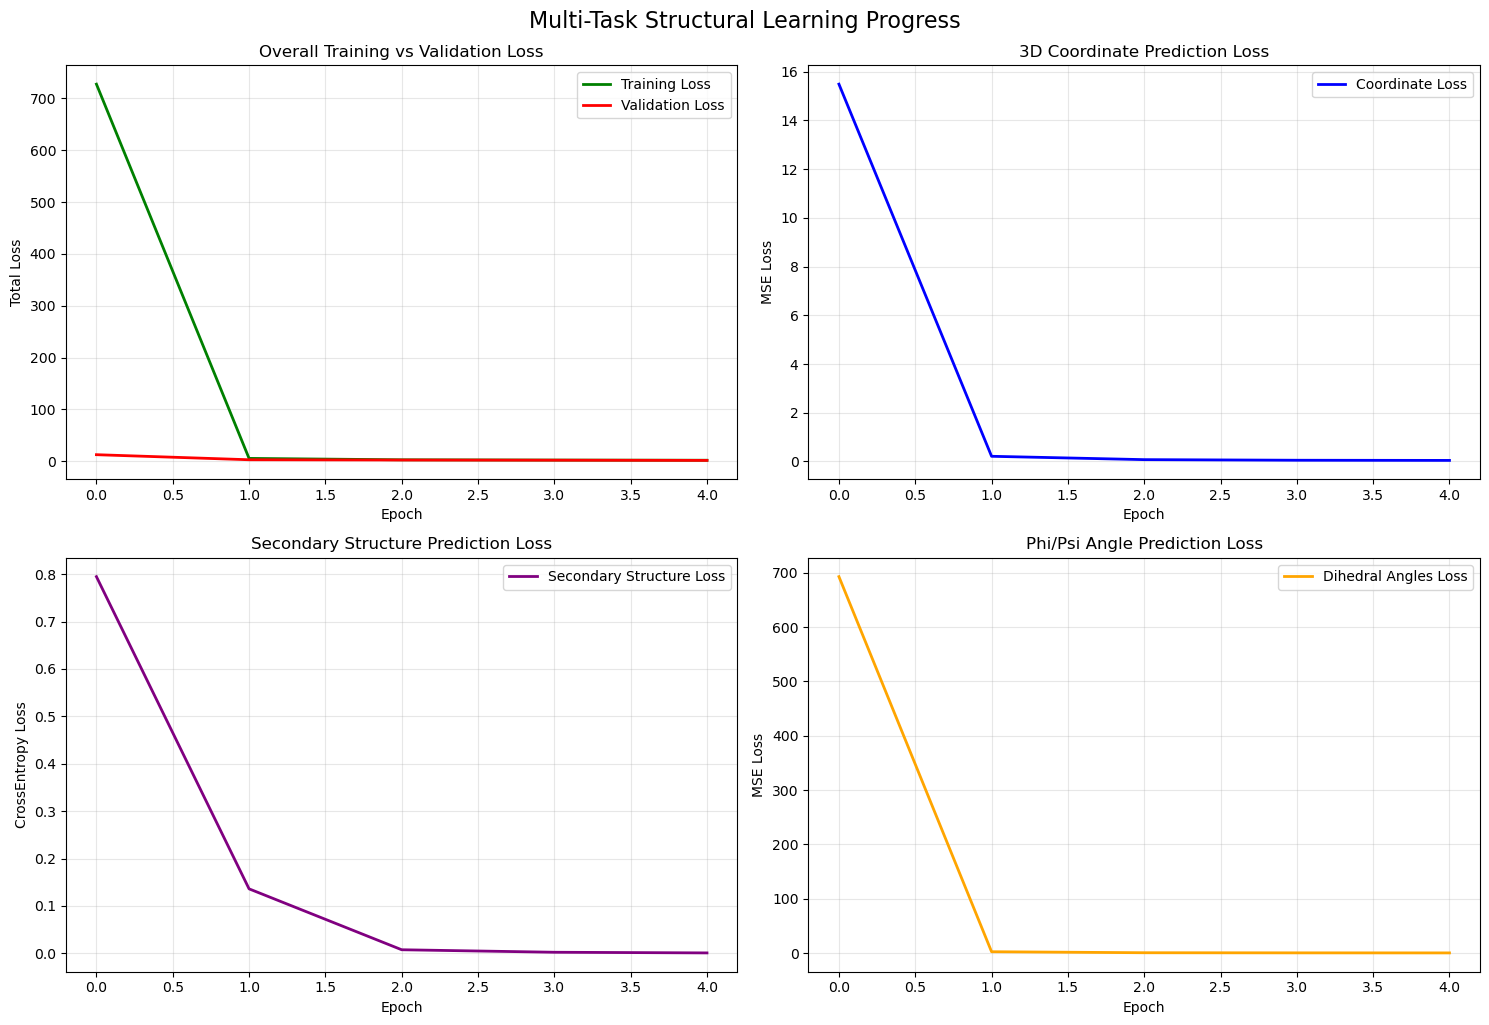

🧬 MULTI-TASK STRUCTURAL LEARNING RESULTS
Final Training Loss: 1.9811
Final Validation Loss: 1.6464

Structural Learning Metrics:
  3D Coordinate Loss: 0.0432
  Secondary Structure Loss: 0.0010
  Dihedral Angles Loss: 0.3904

✅ Model appears to be generalizing well
   Validation loss is within acceptable range

📈 STRUCTURAL LEARNING IMPROVEMENTS:
  3D Coordinate Prediction: 99.7% improvement
  Secondary Structure Prediction: 99.9% improvement
  Dihedral Angle Prediction: 99.9% improvement
  ✅ EXCELLENT coordinate learning - should generate stable structures!

🎯 This model now optimizes for:
  - Sequence accuracy (amino acid prediction)
  - 3D structural stability (coordinate prediction)
  - Secondary structure consistency (H/E/C prediction)
  - Geometric validity (dihedral angle prediction)
  → Should generate much more stable proteins! 🧬


In [ ]:
# Enhanced visualization of multi-task structural learning
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Overall training vs validation loss
axes[0, 0].plot(train_losses, label='Training Loss', color='green', linewidth=2)
axes[0, 0].plot(val_losses, label='Validation Loss', color='red', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Overall Training vs Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Coordinate prediction loss (3D structure)
axes[0, 1].plot(structural_metrics['coord_loss'], label='Coordinate Loss', color='blue', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MSE Loss')
axes[0, 1].set_title('3D Coordinate Prediction Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Secondary structure prediction loss
axes[1, 0].plot(structural_metrics['ss_loss'], label='Secondary Structure Loss', color='purple', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('CrossEntropy Loss')
axes[1, 0].set_title('Secondary Structure Prediction Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Dihedral angle prediction loss
axes[1, 1].plot(structural_metrics['angles_loss'], label='Dihedral Angles Loss', color='orange', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MSE Loss')
axes[1, 1].set_title('Phi/Psi Angle Prediction Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Multi-Task Structural Learning Progress', fontsize=16, y=1.02)
plt.show()

# Print comprehensive results
print("="*60)
print("🧬 MULTI-TASK STRUCTURAL LEARNING RESULTS")
print("="*60)
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"\nStructural Learning Metrics:")
print(f"  3D Coordinate Loss: {structural_metrics['coord_loss'][-1]:.4f}")
print(f"  Secondary Structure Loss: {structural_metrics['ss_loss'][-1]:.4f}")
print(f"  Dihedral Angles Loss: {structural_metrics['angles_loss'][-1]:.4f}")

# Check for overfitting
if val_losses[-1] > train_losses[-1]:
    diff = val_losses[-1] - train_losses[-1]
    print(f"\n⚠️  Validation loss is {diff:.4f} higher than training loss")
    print("   Consider: more regularization, early stopping, or more data")
else:
    print(f"\n✅ Model appears to be generalizing well")
    print("   Validation loss is within acceptable range")

# Structural learning assessment
coord_improvement = (structural_metrics['coord_loss'][0] - structural_metrics['coord_loss'][-1]) / structural_metrics['coord_loss'][0] * 100
ss_improvement = (structural_metrics['ss_loss'][0] - structural_metrics['ss_loss'][-1]) / structural_metrics['ss_loss'][0] * 100
angles_improvement = (structural_metrics['angles_loss'][0] - structural_metrics['angles_loss'][-1]) / structural_metrics['angles_loss'][0] * 100

print(f"\n📈 STRUCTURAL LEARNING IMPROVEMENTS:")
print(f"  3D Coordinate Prediction: {coord_improvement:.1f}% improvement")
print(f"  Secondary Structure Prediction: {ss_improvement:.1f}% improvement") 
print(f"  Dihedral Angle Prediction: {angles_improvement:.1f}% improvement")

if coord_improvement > 50:
    print("  ✅ EXCELLENT coordinate learning - should generate stable structures!")
elif coord_improvement > 30:
    print("  ✅ GOOD coordinate learning - reasonable structural accuracy")
else:
    print("  ⚠️  LIMITED coordinate learning - may need more training or data")

print(f"\n🎯 This model now optimizes for:")
print(f"  - Sequence accuracy (amino acid prediction)")
print(f"  - 3D structural stability (coordinate prediction)")
print(f"  - Secondary structure consistency (H/E/C prediction)")
print(f"  - Geometric validity (dihedral angle prediction)")
print(f"  → Should generate much more stable proteins! 🧬")

# Enhanced Sequence Generation (Reverse Diffusion)

In [ ]:
def generate_enhanced_sequences(num_sequences=5, seq_len=None, num_steps=None, use_mean_features=True):
    """
    Generate new RuBisCO sequences using reverse diffusion with structural features
    """
    if seq_len is None:
        seq_len = max_len
    if num_steps is None:
        num_steps = T
    
    # Set model components to eval mode
    embedding.eval()
    time_mlp.eval() 
    transformer_encoder.eval()
    output_layer.eval()
    coordinate_projection.eval()
    angle_projection.eval()
    neighbor_projection.eval()
    confidence_projection.eval()
    feature_projection.eval()
    
    generated_sequences = []
    
    # Calculate mean structural features from training data if requested
    if use_mean_features:
        mean_coords = train_data['coordinates'].mean(dim=0, keepdim=True)
        mean_phi = train_data['phi_angles'].mean(dim=0, keepdim=True).unsqueeze(-1)
        mean_psi = train_data['psi_angles'].mean(dim=0, keepdim=True).unsqueeze(-1)
        mean_neighbors = train_data['neighbor_counts'].mean(dim=0, keepdim=True).unsqueeze(-1)
        mean_confidence = train_data['confidence_masks'].mean(dim=0, keepdim=True).unsqueeze(-1)
        mean_angles = torch.cat([mean_phi, mean_psi], dim=-1)
        # Add mean secondary structure (assume coil=2 as default)
        mean_ss = torch.full((1, seq_len), 2, dtype=torch.long, device=device)
    
    for seq_idx in range(num_sequences):
        print(f"Generating enhanced sequence {seq_idx + 1}/{num_sequences}...")
        
        # Start from pure noise (random tokens excluding PAD)
        x = torch.randint(1, vocab_size, (1, seq_len), device=device)
        
        # Create a proper mask (assume full sequence length for generation)
        mask = torch.ones_like(x).long()
        
        # Use mean features or None
        if use_mean_features:
            batch_coords = mean_coords
            batch_angles = mean_angles
            batch_neighbors = mean_neighbors
            batch_confidence = mean_confidence
            batch_ss = mean_ss
        else:
            batch_coords = None
            batch_angles = None
            batch_neighbors = None
            batch_confidence = None
            batch_ss = None
        
        # Reverse diffusion process
        for step, t in enumerate(reversed(range(1, num_steps + 1))):
            if step % 100 == 0:
                print(f"  Step {step}/{num_steps}, timestep {t}")
                
            t_tensor = torch.tensor([t], device=device)
            
            with torch.no_grad():
                # Predict the denoised sequence - now including secondary structure
                predicted_outputs = enhanced_rubisco_diffusion_forward(
                    x, t_tensor, mask,
                    coords=batch_coords,
                    angles=batch_angles,
                    neighbors=batch_neighbors,
                    confidence=batch_confidence,
                    secondary_structure=batch_ss
                )
                
                # Extract sequence logits from the multi-task output
                predicted_logits = predicted_outputs['sequence_logits']
                
                if t > 1:
                    # For t > 1, sample from predicted distribution with some noise
                    probs = torch.softmax(predicted_logits / 0.9, dim=-1)  # Temperature scaling
                    x = torch.multinomial(probs.view(-1, vocab_size), 1).view(1, seq_len)
                else:
                    # For t = 1, use greedy decoding (argmax)
                    x = torch.argmax(predicted_logits, dim=-1)
        
        generated_sequences.append(x.cpu())
        
    return generated_sequences

def decode_sequences(encoded_sequences):
    """
    Convert encoded sequences back to amino acid strings
    """
    decoded_sequences = []
    
    for seq_tensor in encoded_sequences:
        seq_indices = seq_tensor.squeeze().tolist()
        
        # Convert indices to amino acids, excluding padding
        amino_acids = []
        for idx in seq_indices:
            if idx == 0:  # PAD token
                break
            amino_acids.append(idx_to_aa[idx])
        
        decoded_sequences.append(''.join(amino_acids))
    
    return decoded_sequences

print("Enhanced generation functions defined")

Enhanced generation functions defined


# Generate Enhanced RuBisCO Sequences

In [ ]:
# Generate 20 new enhanced RuBisCO sequences
print("Generating 20 new enhanced RuBisCO sequences with structural features...")
generated_encoded = generate_enhanced_sequences(num_sequences=20, num_steps=1000, use_mean_features=True)

# Decode to amino acid sequences
generated_sequences = decode_sequences(generated_encoded)

# Display results
print("\n" + "="*60)
print("GENERATED ENHANCED RUBISCO SEQUENCES")
print("(With Structural Features)")
print("="*60)

for i, seq in enumerate(generated_sequences):
    print(f"\nSequence {i+1}:")
    print(f"Length: {len(seq)}")
    print(f"Sequence: {seq}")
    print("-" * 60)

# Summary statistics
lengths = [len(seq) for seq in generated_sequences]
print(f"\nSUMMARY:")
print(f"Generated sequences: {len(generated_sequences)}")
print(f"Average length: {np.mean(lengths):.1f}")
print(f"Min length: {min(lengths)}")
print(f"Max length: {max(lengths)}")

# Save to CSV
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
csv_filename = f"generated_enhanced_rubisco_sequences_{timestamp}.csv"

# Create DataFrame with generated sequences
results_df = pd.DataFrame({
    'ID': [f'Enhanced_RuBisCO_{i+1:03d}' for i in range(len(generated_sequences))],
    'sequence': generated_sequences,
    'length': lengths,
    'generation_method': 'Enhanced_Diffusion_Model_with_Structural_Features'
})

# Save to CSV
results_df.to_csv(csv_filename, index=False)
print(f"\n✓ Enhanced sequences saved to: {csv_filename}")
print(f"CSV contains {len(results_df)} sequences")

# Compare with training data statistics
train_lengths = [len(seq) for seq in train_df['sequence']]
print(f"\nComparison with training data:")
print(f"Training avg length: {np.mean(train_lengths):.1f}")
print(f"Generated avg length: {np.mean(lengths):.1f}")
print(f"Length difference: {abs(np.mean(lengths) - np.mean(train_lengths)):.1f}")

Generating 20 new enhanced RuBisCO sequences with structural features...
Generating enhanced sequence 1/20...
  Step 0/1000, timestep 1000


c:\Users\Nicks\anaconda3\envs\dissertation\Lib\site-packages\torch\nn\modules\transformer.py:408: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at C:\b\abs_fakvb73nko\croot\pytorch-select_1730848725921\work\aten\src\ATen\NestedTensorImpl.cpp:180.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


  Step 100/1000, timestep 900
  Step 200/1000, timestep 800
  Step 200/1000, timestep 800
  Step 300/1000, timestep 700
  Step 300/1000, timestep 700
  Step 400/1000, timestep 600
  Step 400/1000, timestep 600
  Step 500/1000, timestep 500
  Step 500/1000, timestep 500
  Step 600/1000, timestep 400
  Step 600/1000, timestep 400
  Step 700/1000, timestep 300
  Step 700/1000, timestep 300
  Step 800/1000, timestep 200
  Step 800/1000, timestep 200
  Step 900/1000, timestep 100
  Step 900/1000, timestep 100
Generating enhanced sequence 2/20...
  Step 0/1000, timestep 1000
Generating enhanced sequence 2/20...
  Step 0/1000, timestep 1000
  Step 100/1000, timestep 900
  Step 100/1000, timestep 900
  Step 200/1000, timestep 800
  Step 200/1000, timestep 800
  Step 300/1000, timestep 700
  Step 300/1000, timestep 700
  Step 400/1000, timestep 600
  Step 400/1000, timestep 600
  Step 500/1000, timestep 500
  Step 500/1000, timestep 500
  Step 600/1000, timestep 400
  Step 600/1000, timestep 40

# Save Model for Future Use

In [ ]:
# Save model state
model_save_path = f"enhanced_rubisco_diffusion_model_{timestamp}.pth"

torch.save({
    'embedding_state_dict': embedding.state_dict(),
    'time_mlp_state_dict': time_mlp.state_dict(),
    'transformer_encoder_state_dict': transformer_encoder.state_dict(),
    'output_layer_state_dict': output_layer.state_dict(),
    'coordinate_projection_state_dict': coordinate_projection.state_dict(),
    'angle_projection_state_dict': angle_projection.state_dict(),
    'neighbor_projection_state_dict': neighbor_projection.state_dict(),
    'confidence_projection_state_dict': confidence_projection.state_dict(),
    'feature_projection_state_dict': feature_projection.state_dict(),
    'pos_encoding': pos_encoding,
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'model_config': {
        'vocab_size': vocab_size,
        'd_model': d_model,
        'num_heads': num_heads,
        'num_layers': num_layers,
        'd_ff': d_ff,
        'dropout': dropout,
        'max_len': max_len,
        'T': T
    },
    'aa_to_idx': aa_to_idx,
    'idx_to_aa': idx_to_aa
}, model_save_path)

print(f"\n✓ Enhanced model saved to: {model_save_path}")
print(f"Model includes structural feature embeddings and training history")


✓ Enhanced model saved to: enhanced_rubisco_diffusion_model_20250712_111902.pth
Model includes structural feature embeddings and training history


# Training Summary

In [ ]:
print("\n" + "="*60)
print("ENHANCED TRAINING SUMMARY")
print("="*60)
print(f"Training data: {len(train_df)} proteins")
print(f"Validation data: {len(val_df)} proteins")
print(f"Max sequence length: {max_len}")
print(f"Epochs trained: {num_epochs}")
print(f"Final training loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")
print(f"\nStructural features used:")
print(f"  - 3D coordinates")
print(f"  - Phi/Psi angles")
print(f"  - Neighbor counts")
print(f"  - Confidence scores")
print(f"\nGenerated sequences: {len(generated_sequences)}")
print(f"Average generated length: {np.mean(lengths):.1f}")
print(f"\nFiles saved:")
print(f"  - Sequences: {csv_filename}")
print(f"  - Model: {model_save_path}")
print("\n✓ Enhanced diffusion model training completed successfully!")


ENHANCED TRAINING SUMMARY
Training data: 7431 proteins
Validation data: 1858 proteins
Max sequence length: 725
Epochs trained: 5
Final training loss: 1.9811
Final validation loss: 1.6464

Structural features used:
  - 3D coordinates
  - Phi/Psi angles
  - Neighbor counts
  - Confidence scores

Generated sequences: 20
Average generated length: 725.0

Files saved:
  - Sequences: generated_enhanced_rubisco_sequences_20250712_111902.csv
  - Model: enhanced_rubisco_diffusion_model_20250712_111902.pth

✓ Enhanced diffusion model training completed successfully!
